In [1]:
import plumed
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import os   

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_274086/1130076374.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas("../../../metadynamics/run4/run_c/1/COLVAR")
/tmp/ipykernel_274086/1130076374.py:72: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(f"../run_c/COLVAR.{i}")
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_274086/1130076374.py:72: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will b

24
restraint strength: 22933.333333333336 kJ/(mol*nm^2)


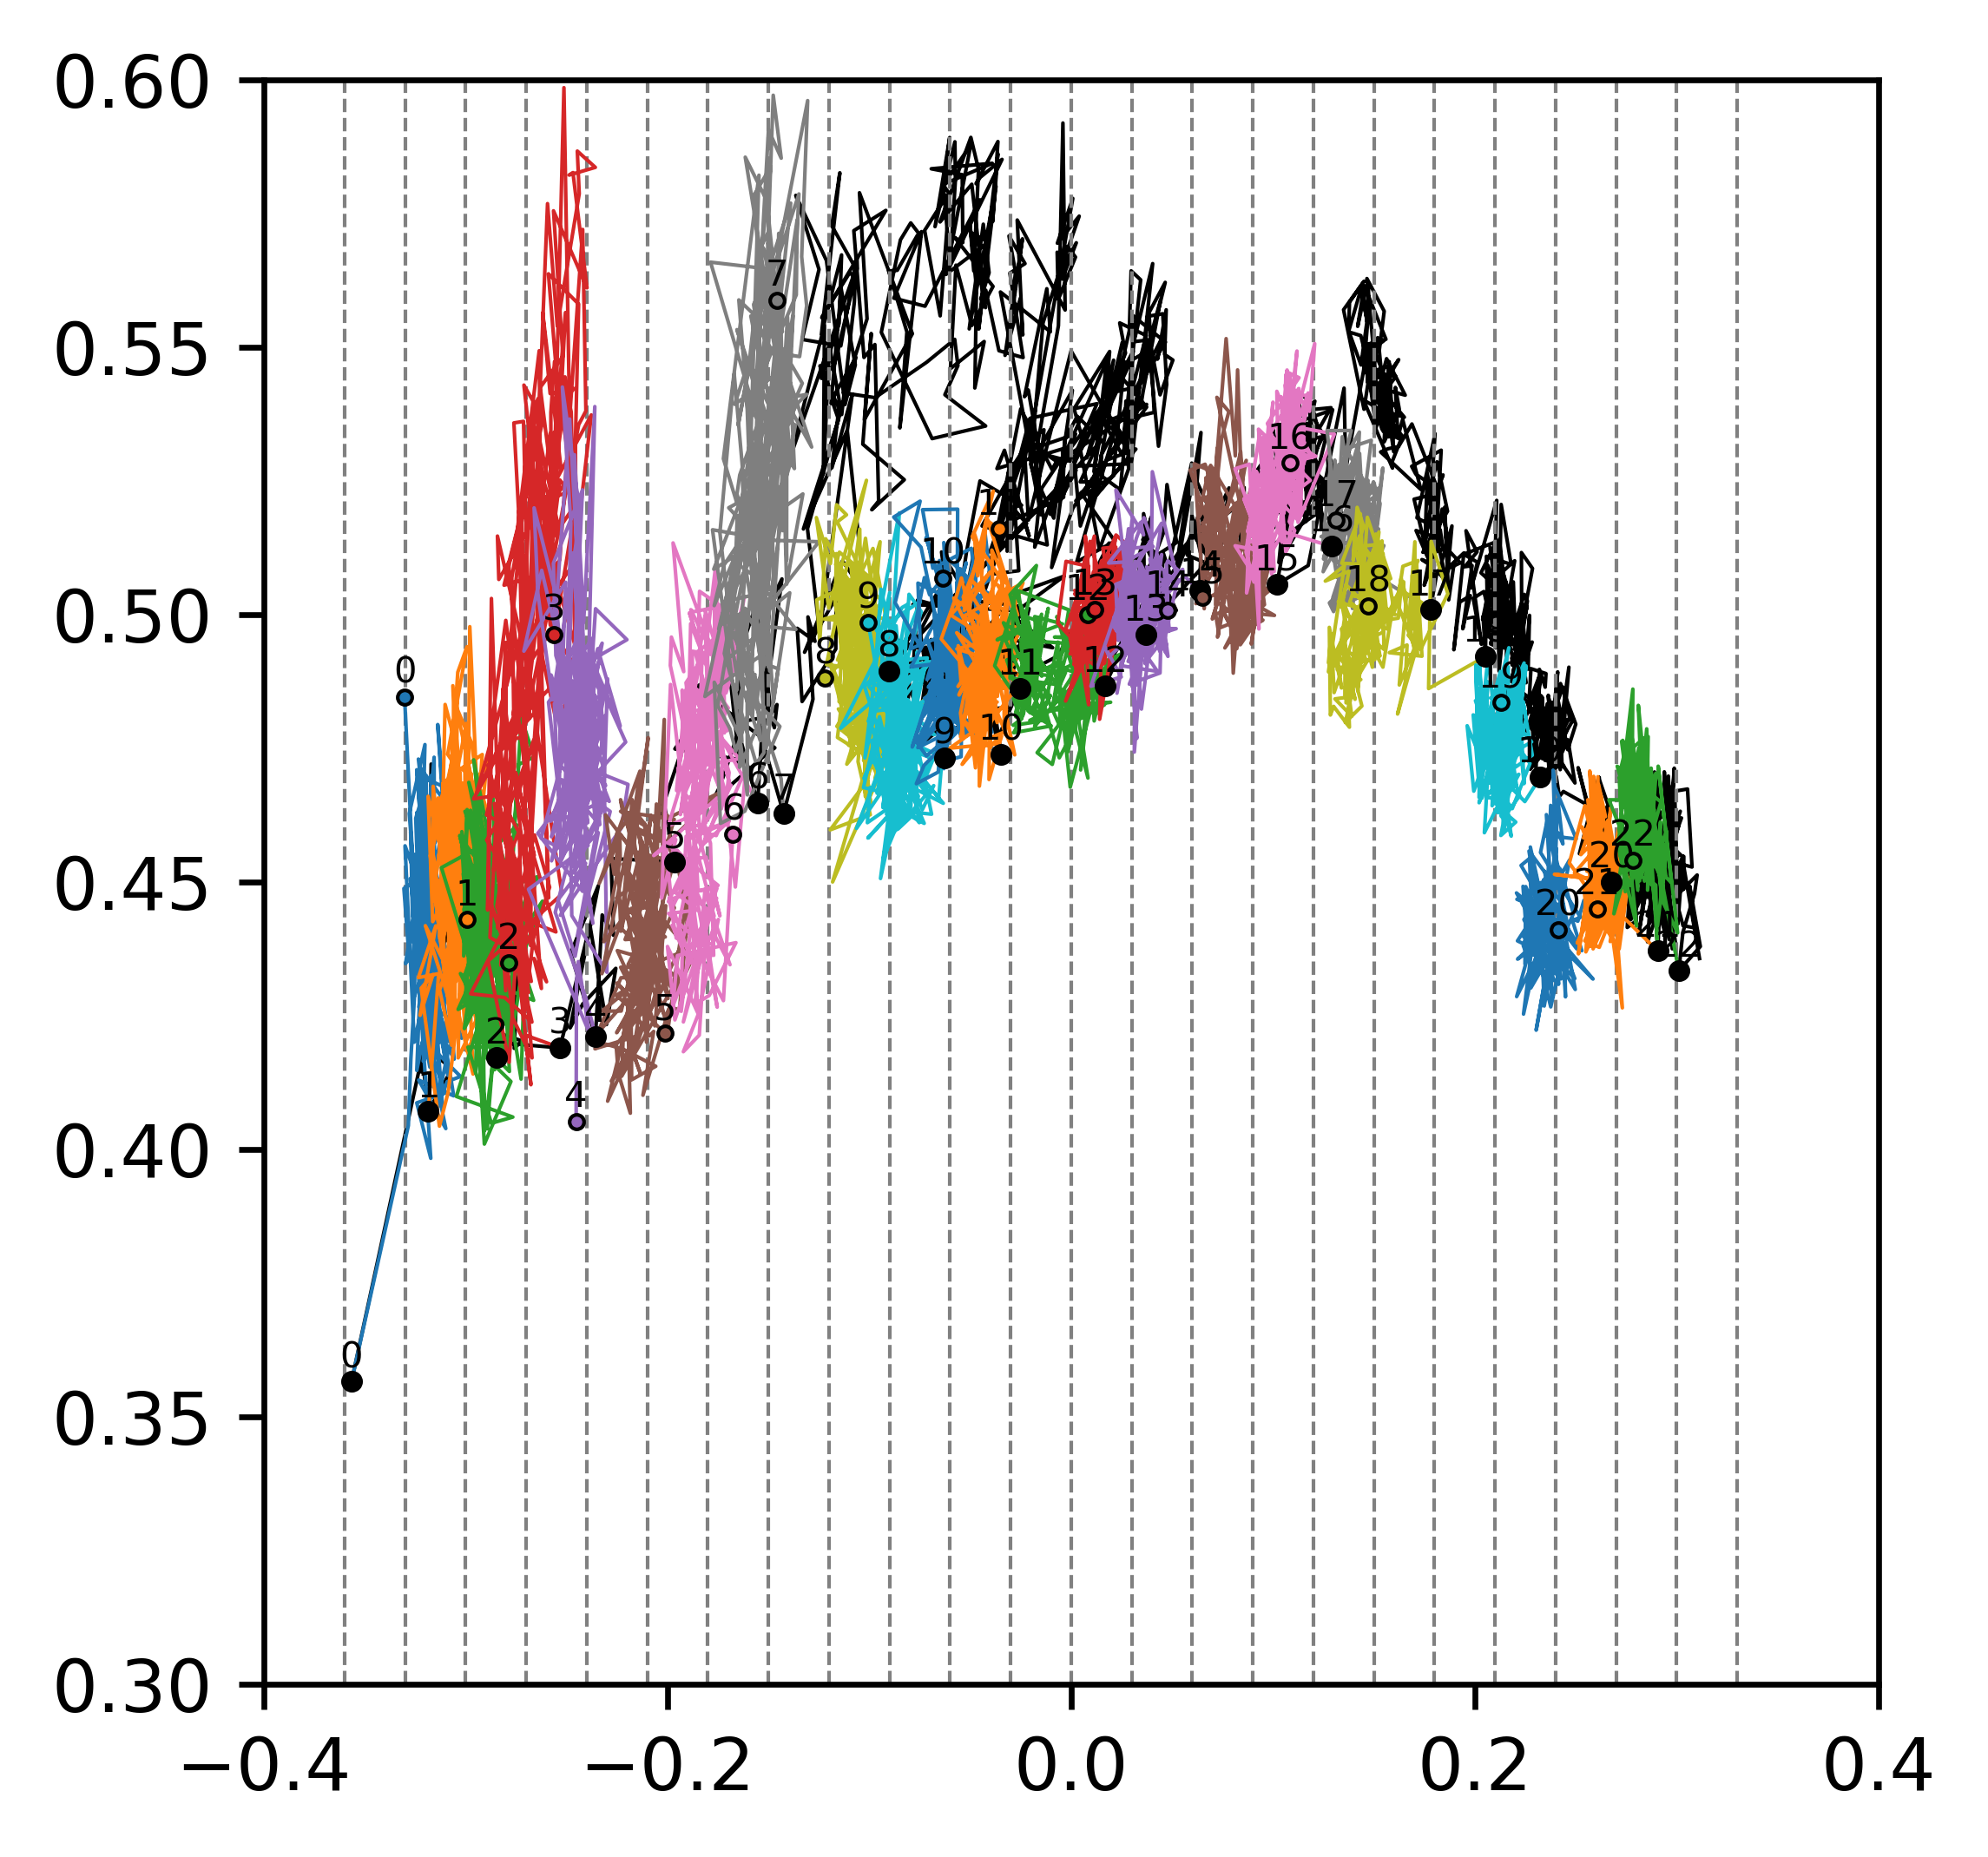

In [27]:
plt.figure(figsize=(4,4),dpi=600)

#----------------------------------------------------------------------------
#load data
colvar=plumed.read_as_pandas("../../../metadynamics/run4/run_c/1/COLVAR")

time = list(colvar.time)

delta = list(colvar.pc_f1b)
pc_c = list(colvar.pc_fc)
pc_m = list(colvar.pc_fm)

sigma = [i+j for i,j in zip(pc_c,pc_m)]

plt.plot(delta, sigma, color="black", linewidth=0.5)

#----------------------------------------------------------------------------
#define windows
winmin = -0.36
winmax = 0.36
winwidth = 0.03
nwindows = int((winmax - winmin)/winwidth)
binbounds = np.arange(winmin,winmax,winwidth)
wincenters = []
print(nwindows)

#calculate restraint strength
#U=kx^2/2 => k=2U/x^2
energy_halfway_between_windows = 2.58  #kJ/mol; 1 kT at T=310.15 K
k_restraint = 2*energy_halfway_between_windows/(winwidth/2)**2
print(f"restraint strength: {k_restraint} kJ/(mol*nm^2)")

#find the frame in each window with the lowest sigma (i.e. the least unfolded one)
t_d_s_bywindow = []

for bbi in range(nwindows-1):
    #track the lowest sigma found so far for each window and the time at which it occurred
    t_d_s = []
    min_sigma = 999
    for t, d, s in zip(time, delta, sigma):
        #if the current frame is within the current window and has a lower sigma, update
        if d > binbounds[bbi] and d < binbounds[bbi+1] and s < min_sigma:
            t_d_s = [t, d, s]
            min_sigma = s
    if len(t_d_s) == 3:
        t_d_s_bywindow.append(t_d_s)
        wincenters.append((binbounds[bbi]+binbounds[bbi+1])/2)


#----------------------------------------------------------------------------
#plot window boundaries and selected points
for bb in binbounds:
    plt.axvline(x=bb, color='grey', linestyle='--', linewidth=0.5)
for bi, bincenter in enumerate(t_d_s_bywindow):
    #print(bincenter)
    plt.scatter(bincenter[1], bincenter[2], color = "black", s=4, zorder = 10000)
    plt.annotate(f"{bi}", (bincenter[1], bincenter[2]), textcoords="offset points", xytext=(0,2), ha='center', color="black", fontsize=5)

plt.xlim(-0.4, 0.4)
plt.ylim(0.3, 0.6)


#----------------------------------------------------------------------------
#load data from each window
for i in range(nwindows):

    if not os.path.exists(f"../run_c/COLVAR.{i}"):
        continue

    #----------------------------------------------------------------------------
    #load data
    colvar=plumed.read_as_pandas(f"../run_c/COLVAR.{i}")

    #time = list(colvar.time)

    pc_c = list(colvar.pc_fc)
    pc_m = list(colvar.pc_fm)

    delta = [i-j for i,j in zip(pc_c,pc_m)]
    sigma = [i+j for i,j in zip(pc_c,pc_m)]

    plt.plot(delta, sigma, linewidth=0.5)
    plt.scatter(delta[-1], sigma[-1], s=4, edgecolors="black", linewidths=0.5, zorder = 10000)
    plt.annotate(f"{i}", (delta[-1], sigma[-1]), textcoords="offset points", xytext=(0,2), ha='center', color="black", fontsize=5)
